In [2]:
import pandas as pd
import glob


#### Merge alle nieuws files samen

In [3]:
files = glob.glob("../../raw/news/nyt_data*.csv")  # pas pad aan
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(df.shape)
print(df.head())

(65641, 5)
                   pub_date  \
0  2016-01-01T02:34:09+0000   
1  2016-01-01T04:42:31+0000   
2  2016-01-01T11:00:16+0000   
3  2016-01-01T21:14:46+0000   
4  2016-01-02T01:48:14+0000   

                                            headline  \
0  new york city and correction officers reach te...   
1  china’s homeless find shelter under mcdonald’s...   
2  the weekly health quiz: sound sleep, coconut o...   
3  at c.d.c., a debate behind recommendations on ...   
4  st. louis area surveys toll as flood risk shif...   

                                            abstract     section  \
0  if approved, the contract would include an 11 ...    New York   
1  in major cities across east asia, downtrodden ...       World   
2    test your knowledge of this week’s health news.      Health   
3  while consensus holds that there is little to ...  Technology   
4  some towns began to let residents in to inspec...        U.S.   

                                             web_url  
0

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65641 entries, 0 to 65640
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pub_date  65641 non-null  str  
 1   headline  65641 non-null  str  
 2   abstract  64831 non-null  str  
 3   section   65641 non-null  str  
 4   web_url   65641 non-null  str  
dtypes: str(5)
memory usage: 2.5 MB


In [5]:
df['pub_date'] = pd.to_datetime(df['pub_date'], format='ISO8601', utc=True)

df['date_key'] = df['pub_date'].dt.strftime('%Y%m%d').astype(int)
df['time_key'] = df['pub_date'].dt.strftime('%H%M%S').astype(int)

In [6]:
df.drop(columns=['pub_date', 'web_url'], inplace=True)

In [7]:
df.head(10)

,headline,abstract,section,date_key,time_key
0,new york city and correction officers reach te...,"if approved, the contract would include an 11 ...",New York,20160101,23409
1,china’s homeless find shelter under mcdonald’s...,"in major cities across east asia, downtrodden ...",World,20160101,44231
2,"the weekly health quiz: sound sleep, coconut o...",test your knowledge of this week’s health news.,Health,20160101,110016
3,"at c.d.c., a debate behind recommendations on ...",while consensus holds that there is little to ...,Technology,20160101,211446
4,st. louis area surveys toll as flood risk shif...,some towns began to let residents in to inspec...,U.S.,20160102,14814
5,qaeda affiliate uses video of donald trump for...,"a video by the shabab, al qaeda’s somalia bran...",World,20160102,35058
6,"for donald trump, lessons from a brother’s suf...","mr. trump, whose appeal is predicated on an au...",U.S.,20160102,162940
7,china grants courts greater autonomy on limite...,china has been making significant reforms to i...,World,20160102,222601
8,uighur identity under siege in china,the chinese government has taken measures to c...,World,20160102,222910
9,donald trump shrugs off appearance in terroris...,donald j. trump said there was little he could...,U.S.,20160103,35456


In [8]:
df['section'].unique()

<StringArray>
[    'New York',        'World',       'Health',   'Technology',
         'U.S.', 'Business Day',   'Your Money',        'Blogs',
  'Real Estate',   'Job Market',    'Education',      'Science',
   'Washington']
Length: 13, dtype: str

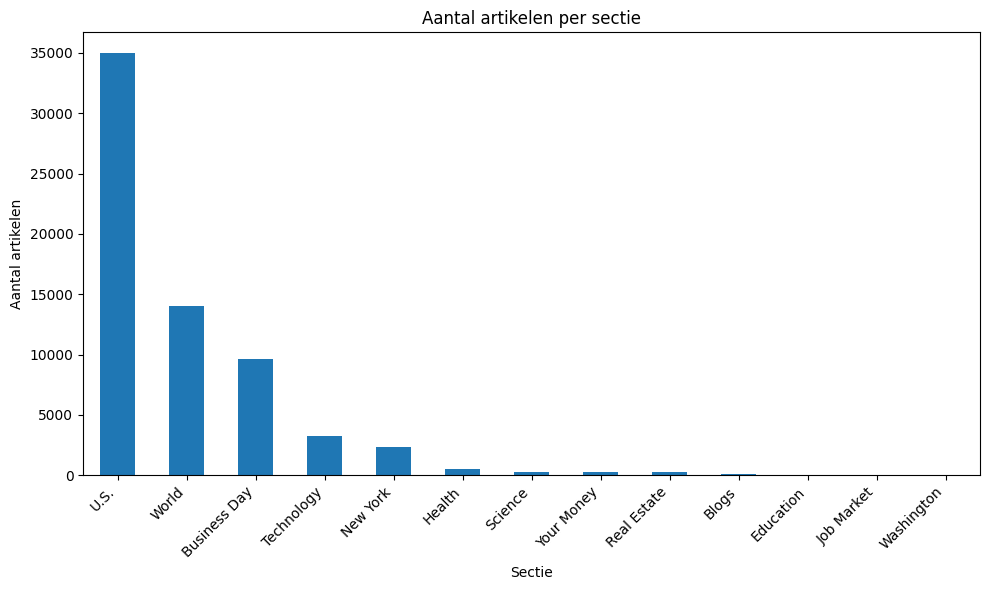

In [9]:
import matplotlib.pyplot as plt

section_counts = df['section'].value_counts()

plt.figure(figsize=(10, 6))
section_counts.plot(kind='bar')
plt.title('Aantal artikelen per sectie')
plt.xlabel('Sectie')
plt.ylabel('Aantal artikelen')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

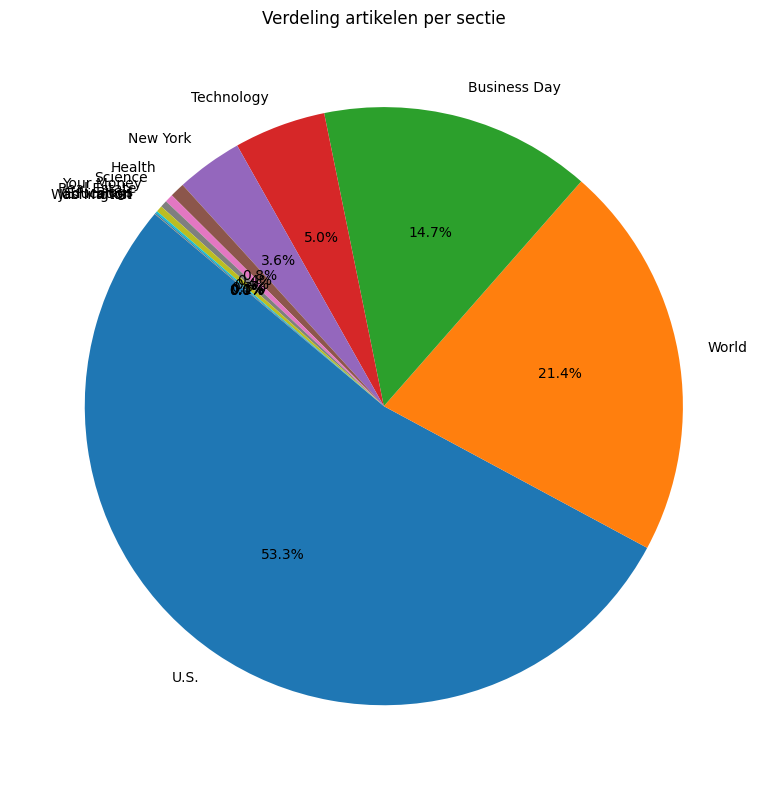

In [10]:
section_counts = df['section'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(
    section_counts,
    labels=section_counts.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Verdeling artikelen per sectie')
plt.tight_layout()
plt.show()

In [11]:
df.head(10)

,headline,abstract,section,date_key,time_key
0,new york city and correction officers reach te...,"if approved, the contract would include an 11 ...",New York,20160101,23409
1,china’s homeless find shelter under mcdonald’s...,"in major cities across east asia, downtrodden ...",World,20160101,44231
2,"the weekly health quiz: sound sleep, coconut o...",test your knowledge of this week’s health news.,Health,20160101,110016
3,"at c.d.c., a debate behind recommendations on ...",while consensus holds that there is little to ...,Technology,20160101,211446
4,st. louis area surveys toll as flood risk shif...,some towns began to let residents in to inspec...,U.S.,20160102,14814
5,qaeda affiliate uses video of donald trump for...,"a video by the shabab, al qaeda’s somalia bran...",World,20160102,35058
6,"for donald trump, lessons from a brother’s suf...","mr. trump, whose appeal is predicated on an au...",U.S.,20160102,162940
7,china grants courts greater autonomy on limite...,china has been making significant reforms to i...,World,20160102,222601
8,uighur identity under siege in china,the chinese government has taken measures to c...,World,20160102,222910
9,donald trump shrugs off appearance in terroris...,donald j. trump said there was little he could...,U.S.,20160103,35456
